DEVICE: cuda
Using font: TlwgTypewriter Oblique.ttf

COMMON_KH, COMMON_KW: 24 20
COMMON_ANCHOR: 10 12


detector eval:   0%|          | 0/1000 [00:00<?, ?it/s]


===== Detector Evaluation: all scenes =====
n: 1000
scene_exact_acc: 0.9980
exact_letter_set_acc: 0.9990
exact_color_set_acc: 1.0000
exact_position_set_acc: 0.9980
object_letter_acc: 0.9997
object_color_acc: 1.0000
object_position_acc: 0.9993
object_full_tuple_acc: 0.9993

===== Detector Evaluation: clean scenes only =====
n: 1000
scene_exact_acc: 0.9980
exact_letter_set_acc: 0.9990
exact_color_set_acc: 1.0000
exact_position_set_acc: 0.9980
object_letter_acc: 0.9997
object_color_acc: 1.0000
object_position_acc: 0.9993
object_full_tuple_acc: 0.9993

===== Detector Evaluation: fallback-overlap scenes only =====
No samples.

Fallback-overlap scene ratio: 0.0


detector eval:   0%|          | 0/100 [00:00<?, ?it/s]


===== Detector Evaluation: all scenes =====
n: 100
scene_exact_acc: 1.0000
exact_letter_set_acc: 1.0000
exact_color_set_acc: 1.0000
exact_position_set_acc: 1.0000
object_letter_acc: 1.0000
object_color_acc: 1.0000
object_position_acc: 1.0000
object_full_tuple_acc: 1.0000

===== Detector Evaluation: clean scenes only =====
n: 100
scene_exact_acc: 1.0000
exact_letter_set_acc: 1.0000
exact_color_set_acc: 1.0000
exact_position_set_acc: 1.0000
object_letter_acc: 1.0000
object_color_acc: 1.0000
object_position_acc: 1.0000
object_full_tuple_acc: 1.0000

===== Detector Evaluation: fallback-overlap scenes only =====
No samples.

Fallback-overlap scene ratio: 0.0


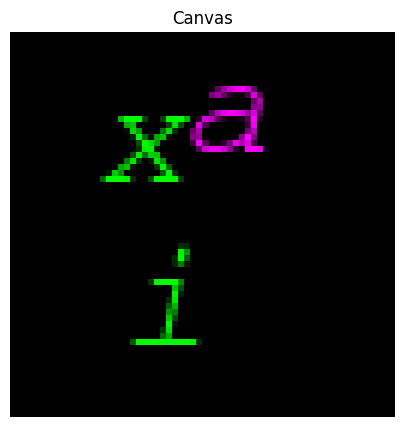

Ground truth:
  x  green  x=22  y=20
  i  green  x=26  y=44
  a  magenta  x=36  y=15
Detected:
  x  green  x=22  y=20
  i  green  x=26  y=44
  a  magenta  x=36  y=15


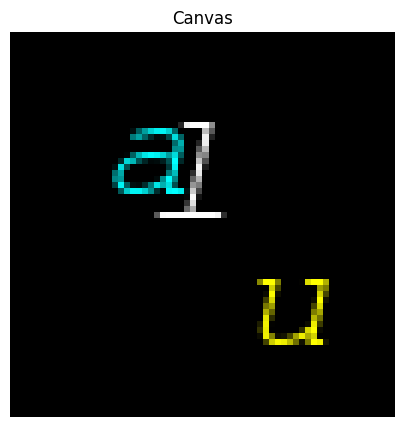

Ground truth:
  a  cyan  x=23  y=22
  l  white  x=30  y=23
  u  yellow  x=46  y=47
Detected:
  a  cyan  x=23  y=22
  l  white  x=30  y=23
  u  yellow  x=46  y=47


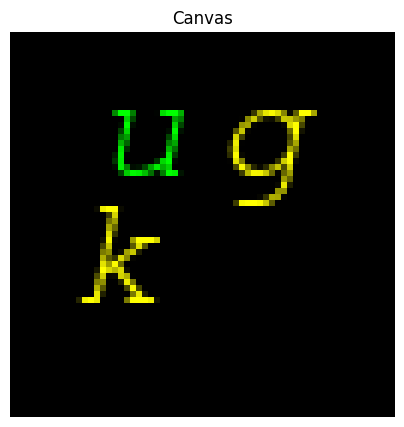

Ground truth:
  k  yellow  x=18  y=37
  u  green  x=22  y=19
  g  yellow  x=43  y=21
Detected:
  k  yellow  x=18  y=37
  u  green  x=22  y=19
  g  yellow  x=43  y=21


In [2]:
import os
import random
from dataclasses import dataclass
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from PIL import ImageFont
from tqdm.notebook import tqdm


# ============================================================
# Config
# ============================================================

SEED = 0
IMG_SIZE = 64
FONT_SIZE = 26

LETTERS = "abcdefghijklmnopqrstuvwxyz"
COLOR_NAMES = ["red", "green", "blue", "cyan", "magenta", "yellow", "white"]

N_LETTERS = len(LETTERS)
N_COLORS = len(COLOR_NAMES)

FONT_CANDIDATES = [
    "TlwgTypewriter Oblique.ttf",
    "TlwgTypewriter-Oblique.ttf",
]

SHIFT_MIN = -19
SHIFT_MAX = 19
MAX_PLACEMENT_RETRIES = 20
USE_INTEGER_SHIFT = True

TOP_K = 3

# speed and accuracy knobs
FAST_TOPK = 800
NMS_CENTER_DIST = 2
COLOR_ERROR_THRESH = 0.05
REFINE_RADIUS = 2
EXPLAIN_AWAY_FACTOR = 1.0
MASK_THRESH = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

COLOR_TABLE = {
    "red":     np.array([1.0, 0.0, 0.0], dtype=np.float32),
    "green":   np.array([0.0, 1.0, 0.0], dtype=np.float32),
    "blue":    np.array([0.0, 0.0, 1.0], dtype=np.float32),
    "cyan":    np.array([0.0, 1.0, 1.0], dtype=np.float32),
    "magenta": np.array([1.0, 0.0, 1.0], dtype=np.float32),
    "yellow":  np.array([1.0, 1.0, 0.0], dtype=np.float32),
    "white":   np.array([1.0, 1.0, 1.0], dtype=np.float32),
}

COLOR_TO_IDX = {c: i for i, c in enumerate(COLOR_NAMES)}
IDX_TO_COLOR = {i: c for i, c in enumerate(COLOR_NAMES)}
LETTER_TO_IDX = {c: i for i, c in enumerate(LETTERS)}
IDX_TO_LETTER = {i: c for i, c in enumerate(LETTERS)}


def seed_all(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_all(SEED)


@dataclass
class Detection:
    letter_idx: int
    color_idx: int
    x: int
    y: int
    score: float
        
# ============================================================
# Font rendering
# ============================================================

def find_font_path():
    for p in FONT_CANDIDATES:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(
        f"Could not find font file. Tried: {FONT_CANDIDATES}. "
        f"Put the font in the same directory as this notebook."
    )


FONT_PATH = find_font_path()
print("Using font:", FONT_PATH)


def render_letter_64(letter):
    font = ImageFont.truetype(FONT_PATH, size=FONT_SIZE)
    font_obj = font.getmask(letter, stroke_width=0)

    imtext = np.array(font_obj, dtype=np.float32)
    w, h = font_obj.size
    imtext = imtext.reshape((h, w)) / 255.0

    canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    r = int(np.floor((IMG_SIZE - h) / 2))
    c = int(np.floor((IMG_SIZE - w) / 2))

    r1 = max(0, r)
    c1 = max(0, c)
    r2 = min(IMG_SIZE, r + h)
    c2 = min(IMG_SIZE, c + w)

    tr1 = r1 - r
    tc1 = c1 - c
    tr2 = tr1 + (r2 - r1)
    tc2 = tc1 + (c2 - c1)

    canvas[r1:r2, c1:c2] = imtext[tr1:tr2, tc1:tc2]
    return canvas


def crop_nonzero(img, pad=1):
    ys, xs = np.where(img > 1e-6)
    if len(xs) == 0:
        return img, (0, 0, img.shape[1], img.shape[0])

    x1 = max(0, xs.min() - pad)
    x2 = min(img.shape[1], xs.max() + pad + 1)
    y1 = max(0, ys.min() - pad)
    y2 = min(img.shape[0], ys.max() + pad + 1)

    return img[y1:y2, x1:x2], (x1, y1, x2, y2)


FULL_TEMPLATES = []
CROPPED_TEMPLATES = []
CROP_BOXES = []

for ch in LETTERS:
    full = render_letter_64(ch)
    crop, box = crop_nonzero(full, pad=1)
    FULL_TEMPLATES.append(full)
    CROPPED_TEMPLATES.append(crop)
    CROP_BOXES.append(box)

FULL_TEMPLATES = np.stack(FULL_TEMPLATES, axis=0).astype(np.float32)



# ============================================================
# Anchor-aligned common kernels
# Correct version: common size must cover max left/right/up/down extents
# ============================================================

left_extents = []
right_extents = []
up_extents = []
down_extents = []

for li, crop in enumerate(CROPPED_TEMPLATES):
    h, w = crop.shape
    x1, y1, x2, y2 = CROP_BOXES[li]

    # anchor is the original 64x64 center inside the crop
    anchor_x = IMG_SIZE // 2 - x1
    anchor_y = IMG_SIZE // 2 - y1

    left_extents.append(anchor_x)
    right_extents.append(w - anchor_x)

    up_extents.append(anchor_y)
    down_extents.append(h - anchor_y)

MAX_LEFT = int(max(left_extents))
MAX_RIGHT = int(max(right_extents))
MAX_UP = int(max(up_extents))
MAX_DOWN = int(max(down_extents))

COMMON_KW = MAX_LEFT + MAX_RIGHT
COMMON_KH = MAX_UP + MAX_DOWN

COMMON_ANCHOR_X = MAX_LEFT
COMMON_ANCHOR_Y = MAX_UP

print("\nCOMMON_KH, COMMON_KW:", COMMON_KH, COMMON_KW)
print("COMMON_ANCHOR:", COMMON_ANCHOR_X, COMMON_ANCHOR_Y)

COMMON_KERNELS_np = []
COMMON_MASKS_np = []

for li, crop in enumerate(CROPPED_TEMPLATES):
    h, w = crop.shape
    x1, y1, x2, y2 = CROP_BOXES[li]

    anchor_x = IMG_SIZE // 2 - x1
    anchor_y = IMG_SIZE // 2 - y1

    insert_x = COMMON_ANCHOR_X - anchor_x
    insert_y = COMMON_ANCHOR_Y - anchor_y

    kernel = np.zeros((COMMON_KH, COMMON_KW), dtype=np.float32)
    mask = np.zeros((COMMON_KH, COMMON_KW), dtype=np.float32)

    assert insert_x >= 0
    assert insert_y >= 0
    assert insert_x + w <= COMMON_KW
    assert insert_y + h <= COMMON_KH

    kernel[insert_y:insert_y + h, insert_x:insert_x + w] = crop
    mask[insert_y:insert_y + h, insert_x:insert_x + w] = (crop > MASK_THRESH).astype(np.float32)

    COMMON_KERNELS_np.append(kernel)
    COMMON_MASKS_np.append(mask)

COMMON_KERNELS_np = np.stack(COMMON_KERNELS_np, axis=0).astype(np.float32)
COMMON_MASKS_np = np.stack(COMMON_MASKS_np, axis=0).astype(np.float32)

COMMON_KERNELS = torch.tensor(COMMON_KERNELS_np, dtype=torch.float32, device=DEVICE)[:, None, :, :]
COMMON_MASKS = torch.tensor(COMMON_MASKS_np, dtype=torch.float32, device=DEVICE)[:, None, :, :]

COMMON_ONES = torch.ones_like(COMMON_KERNELS, dtype=torch.float32, device=DEVICE)

COMMON_AREAS = COMMON_MASKS.sum(dim=(1, 2, 3), keepdim=True).clamp(min=1.0)
COMMON_MASKED_KERNELS = COMMON_KERNELS * COMMON_MASKS

# ============================================================
# Color prototypes on GPU
# ============================================================

COLOR_PROTO_T = torch.tensor(
    np.stack([COLOR_TABLE[c] for c in COLOR_NAMES], axis=0),
    dtype=torch.float32,
    device=DEVICE,
).view(N_COLORS, 3, 1, 1)

COLOR_DENOM_T = (COLOR_PROTO_T * COLOR_PROTO_T).sum(dim=1) + 1e-8


# ============================================================
# Scene generation
# ============================================================

def shift_2d_integer(img, dx, dy):
    out = np.zeros_like(img)

    src_x1 = max(0, -dx)
    src_x2 = min(IMG_SIZE, IMG_SIZE - dx) if dx >= 0 else IMG_SIZE
    dst_x1 = max(0, dx)
    dst_x2 = dst_x1 + (src_x2 - src_x1)

    src_y1 = max(0, -dy)
    src_y2 = min(IMG_SIZE, IMG_SIZE - dy) if dy >= 0 else IMG_SIZE
    dst_y1 = max(0, dy)
    dst_y2 = dst_y1 + (src_y2 - src_y1)

    if src_x2 > src_x1 and src_y2 > src_y1:
        out[dst_y1:dst_y2, dst_x1:dst_x2] = img[src_y1:src_y2, src_x1:src_x2]

    return out


def render_one_colored_letter(letter_idx, color_idx, dx, dy):
    base = FULL_TEMPLATES[int(letter_idx)]
    shifted = shift_2d_integer(base, int(dx), int(dy))

    color = COLOR_TABLE[IDX_TO_COLOR[int(color_idx)]]
    rgb = shifted[None, :, :] * color[:, None, None]
    return rgb.astype(np.float32)


def overlap_pixels(existing_canvas, candidate, thresh=1e-4):
    return int(np.sum((existing_canvas > thresh) & (candidate > thresh)))


def sample_shift(rng):
    if USE_INTEGER_SHIFT:
        dx = int(rng.integers(SHIFT_MIN, SHIFT_MAX + 1))
        dy = int(rng.integers(SHIFT_MIN, SHIFT_MAX + 1))
    else:
        dx = float(rng.uniform(SHIFT_MIN, SHIFT_MAX))
        dy = float(rng.uniform(SHIFT_MIN, SHIFT_MAX))
    return dx, dy


def generate_one_scene(rng):
    canvas = np.zeros((3, IMG_SIZE, IMG_SIZE), dtype=np.float32)
    scene = []
    used_centers = set()
    used_fallback_overlap = False

    for _ in range(3):
        last_valid_center_candidate = None
        placed = False

        for attempt in range(MAX_PLACEMENT_RETRIES):
            letter_idx = int(rng.integers(0, N_LETTERS))
            color_idx = int(rng.integers(0, N_COLORS))
            dx, dy = sample_shift(rng)

            candidate = render_one_colored_letter(letter_idx, color_idx, dx, dy)

            x = int(np.round(IMG_SIZE // 2 + dx))
            y = int(np.round(IMG_SIZE // 2 + dy))
            x = max(0, min(IMG_SIZE - 1, x))
            y = max(0, min(IMG_SIZE - 1, y))

            if (x, y) in used_centers:
                continue

            last_valid_center_candidate = (letter_idx, color_idx, x, y, candidate)

            if overlap_pixels(canvas, candidate) < 1:
                canvas = np.maximum(canvas, candidate)
                scene.append((letter_idx, color_idx, x, y))
                used_centers.add((x, y))
                placed = True
                break

        if not placed:
            if last_valid_center_candidate is None:
                raise RuntimeError("Failed to sample a new letter with a unique center.")

            letter_idx, color_idx, x, y, candidate = last_valid_center_candidate
            canvas = np.maximum(canvas, candidate)
            scene.append((letter_idx, color_idx, x, y))
            used_centers.add((x, y))
            used_fallback_overlap = True

    scene = sorted(scene, key=lambda z: (z[2], z[3], z[0], z[1]))
    return canvas, np.array(scene, dtype=np.int16), used_fallback_overlap


# ============================================================
# Fast color-separated maps
# ============================================================

def color_shape_maps_torch(canvas):
    """
    canvas: numpy [3,64,64]
    return: torch [7,64,64]
    """
    x = torch.as_tensor(canvas, dtype=torch.float32, device=DEVICE).unsqueeze(0)  # [1,3,H,W]

    numerator = (x * COLOR_PROTO_T.unsqueeze(0)).sum(dim=2).squeeze(0)  # [7,H,W]
    response = numerator / COLOR_DENOM_T

    reconstructed = response[:, None, :, :] * COLOR_PROTO_T  # [7,3,H,W]
    error = ((x.squeeze(0).unsqueeze(0) - reconstructed) ** 2).mean(dim=1)

    response = response.clone()
    response[error > COLOR_ERROR_THRESH] = 0.0
    response = torch.clamp(response, 0.0, 1.0)

    return response


# ============================================================
# Accuracy-recovered common-kernel detector
# Fast common kernels propose candidates.
# Original crop-specific NCC re-scores top candidates.
# ============================================================

FAST_TOPK = 3000
EXACT_RESCORER_TOP = 10
REFINE_RADIUS = 1
NMS_CENTER_DIST = 0
EXPLAIN_AWAY_FACTOR = 1.0


def crop_top_left_from_center_exact(letter_idx, x_center, y_center):
    crop_x1, crop_y1, _, _ = CROP_BOXES[letter_idx]
    px = int(round(x_center - (IMG_SIZE // 2 - crop_x1)))
    py = int(round(y_center - (IMG_SIZE // 2 - crop_y1)))
    return px, py


def exact_ncc_at(shape_map, letter_idx, x_center, y_center, eps=1e-6):
    """
    Crop-specific NCC at one proposed center.
    This matches the old variable-size detector's support more closely.
    """
    crop = CROPPED_TEMPLATES[letter_idx].astype(np.float32)
    crop = crop / (crop.sum() + 1e-8)

    px, py = crop_top_left_from_center_exact(letter_idx, x_center, y_center)

    h, w = crop.shape
    x1, y1 = px, py
    x2, y2 = px + w, py + h

    if x1 < 0 or y1 < 0 or x2 > IMG_SIZE or y2 > IMG_SIZE:
        return -1e9

    patch = shape_map[y1:y2, x1:x2].astype(np.float32)

    k0 = crop - crop.mean()
    p0 = patch - patch.mean()

    denom = np.sqrt(np.sum(k0 * k0) * np.sum(p0 * p0)) + eps
    return float(np.sum(k0 * p0) / denom)


def refine_position_exact(shape_maps_np, canvas, letter_idx, color_idx, x, y, search_radius=REFINE_RADIUS):
    """
    Local refinement using the exact crop-specific NCC score.
    """
    shape_map = shape_maps_np[color_idx]

    best_x, best_y = int(x), int(y)
    best_score = -1e9

    for yy in range(max(0, y - search_radius), min(IMG_SIZE, y + search_radius + 1)):
        for xx in range(max(0, x - search_radius), min(IMG_SIZE, x + search_radius + 1)):
            score = exact_ncc_at(shape_map, letter_idx, xx, yy)
            if score > best_score:
                best_score = score
                best_x, best_y = int(xx), int(yy)

    return best_x, best_y, best_score


def estimate_color_by_exact_mask(canvas, letter_idx, x_center, y_center, mask_thresh=0.1):
    """
    Color readout using original crop-specific support.
    """
    crop = CROPPED_TEMPLATES[letter_idx]
    px, py = crop_top_left_from_center_exact(letter_idx, x_center, y_center)

    h, w = crop.shape
    x1, y1 = px, py
    x2, y2 = px + w, py + h

    cx1, cy1 = max(0, x1), max(0, y1)
    cx2, cy2 = min(IMG_SIZE, x2), min(IMG_SIZE, y2)

    if cx1 >= cx2 or cy1 >= cy2:
        return 0

    mx1, my1 = cx1 - x1, cy1 - y1
    mx2, my2 = mx1 + (cx2 - cx1), my1 + (cy2 - cy1)

    mask = crop[my1:my2, mx1:mx2] > mask_thresh
    patch = canvas[:, cy1:cy2, cx1:cx2]

    if mask.sum() == 0:
        return 0

    mean_rgb = patch[:, mask].mean(axis=1)

    best_idx = min(
        range(N_COLORS),
        key=lambda i: float(np.sum((mean_rgb - COLOR_TABLE[IDX_TO_COLOR[i]]) ** 2))
    )
    return int(best_idx)


def render_detected_object_exact(letter_idx, color_idx, x_center, y_center):
    """
    Render detected object using original crop-specific support.
    """
    crop = CROPPED_TEMPLATES[letter_idx]
    color = COLOR_TABLE[IDX_TO_COLOR[color_idx]]

    px, py = crop_top_left_from_center_exact(letter_idx, x_center, y_center)

    h, w = crop.shape
    x1, y1 = px, py
    x2, y2 = px + w, py + h

    out = np.zeros((3, IMG_SIZE, IMG_SIZE), dtype=np.float32)

    cx1, cy1 = max(0, x1), max(0, y1)
    cx2, cy2 = min(IMG_SIZE, x2), min(IMG_SIZE, y2)

    if cx1 >= cx2 or cy1 >= cy2:
        return out

    mx1, my1 = cx1 - x1, cy1 - y1
    mx2, my2 = mx1 + (cx2 - cx1), my1 + (cy2 - cy1)

    mask = crop[my1:my2, mx1:mx2]
    patch_rgb = mask[None, :, :] * color[:, None, None]

    out[:, cy1:cy2, cx1:cx2] = patch_rgb
    return out


def subtract_detected_object(canvas, det, factor=EXPLAIN_AWAY_FACTOR):
    obj = render_detected_object_exact(
        letter_idx=det.letter_idx,
        color_idx=det.color_idx,
        x_center=det.x,
        y_center=det.y,
    )
    residual = canvas - factor * obj
    residual = np.clip(residual, 0.0, 1.0)
    return residual


def too_close_xy(x, y, points, min_dist=NMS_CENTER_DIST):
    for px, py in points:
        dx = x - px
        dy = y - py
        if dx * dx + dy * dy <= min_dist * min_dist:
            return True
    return False

def ncc_heatmap_common(x):
    eps = 1e-6

    x_sum = F.conv2d(x, COMMON_MASKS)
    x2_sum = F.conv2d(x * x, COMMON_MASKS)

    area = COMMON_AREAS.view(1, N_LETTERS, 1, 1)
    x_mean = x_sum / area
    x_var = torch.clamp(x2_sum - area * x_mean * x_mean, min=0.0)
    x_norm = torch.sqrt(x_var + eps)

    k_sum = COMMON_MASKED_KERNELS.sum(dim=(1, 2, 3), keepdim=True)
    k_mean = k_sum / COMMON_AREAS
    k0 = (COMMON_KERNELS - k_mean) * COMMON_MASKS
    k_norm = torch.sqrt((k0 * k0).sum(dim=(1, 2, 3), keepdim=True) + eps)

    num = F.conv2d(x, k0)
    scores = num / (x_norm * k_norm.view(1, N_LETTERS, 1, 1) + eps)
    return scores

def score_all_candidates(canvas):
    shape_maps = color_shape_maps_torch(canvas)
    x = shape_maps[:, None, :, :]

    with torch.no_grad():
        scores = ncc_heatmap_common(x)

    return scores

def detect_one_object_common_calibrated(canvas, banned_positions=None):
    """
    Fast proposal from common-kernel NCC.
    Accurate acceptance from original crop-specific NCC.
    """
    if banned_positions is None:
        banned_positions = []

    scores = score_all_candidates(canvas)  # [7,26,Hout,Wout]

    flat = scores.reshape(-1)
    k = min(FAST_TOPK, flat.numel())
    vals, idxs = torch.topk(flat, k=k)

    _, _, Hout, Wout = scores.shape

    vals_np = vals.detach().cpu().numpy()
    idxs_np = idxs.detach().cpu().numpy()

    shape_maps_np = color_shape_maps_torch(canvas).detach().cpu().numpy()

    rough_candidates = []
    seen = set()

    for val, idx in zip(vals_np, idxs_np):
        idx = int(idx)

        px = idx % Wout
        tmp = idx // Wout
        py = tmp % Hout
        tmp = tmp // Hout
        letter_idx = tmp % N_LETTERS
        color_idx = tmp // N_LETTERS

        x_center, y_center = common_center_from_top_left(px, py)

        if x_center < 0 or x_center >= IMG_SIZE or y_center < 0 or y_center >= IMG_SIZE:
            continue

        if too_close_xy(x_center, y_center, banned_positions):
            continue

        key = (letter_idx, color_idx, x_center, y_center)
        if key in seen:
            continue
        seen.add(key)

        rough_candidates.append(
            Detection(
                letter_idx=int(letter_idx),
                color_idx=int(color_idx),
                x=int(x_center),
                y=int(y_center),
                score=float(val),
            )
        )

        if len(rough_candidates) >= EXACT_RESCORER_TOP:
            break

    if len(rough_candidates) == 0:
        return None

    refined_candidates = []

    for cand in rough_candidates:
        x_refined, y_refined, exact_score = refine_position_exact(
            shape_maps_np=shape_maps_np,
            canvas=canvas,
            letter_idx=cand.letter_idx,
            color_idx=cand.color_idx,
            x=cand.x,
            y=cand.y,
            search_radius=REFINE_RADIUS,
        )

        if too_close_xy(x_refined, y_refined, banned_positions):
            continue

        color_refined = estimate_color_by_exact_mask(
            canvas=canvas,
            letter_idx=cand.letter_idx,
            x_center=x_refined,
            y_center=y_refined,
            mask_thresh=MASK_THRESH,
        )

        # Re-score once using the refined color, because color can change after mask readout.
        exact_score_refined = exact_ncc_at(
            shape_maps_np[color_refined],
            cand.letter_idx,
            x_refined,
            y_refined,
        )

        refined_candidates.append(
            Detection(
                letter_idx=cand.letter_idx,
                color_idx=color_refined,
                x=x_refined,
                y=y_refined,
                score=exact_score_refined,
            )
        )

    if len(refined_candidates) == 0:
        return None

    refined_candidates.sort(key=lambda z: z.score, reverse=True)

    for det in refined_candidates:
        if not too_close_xy(det.x, det.y, banned_positions):
            return det

    return None


# ============================================================
# Fast batched confusion + position reranker
# ============================================================

from itertools import product

CONFUSION_SETS = {
    LETTER_TO_IDX["n"]: [LETTER_TO_IDX["n"], LETTER_TO_IDX["h"]],
    LETTER_TO_IDX["h"]: [LETTER_TO_IDX["h"], LETTER_TO_IDX["n"]],
    LETTER_TO_IDX["v"]: [LETTER_TO_IDX["v"], LETTER_TO_IDX["y"]],
    LETTER_TO_IDX["y"]: [LETTER_TO_IDX["y"], LETTER_TO_IDX["v"]],
    LETTER_TO_IDX["t"]: [LETTER_TO_IDX["t"], LETTER_TO_IDX["f"]],
    LETTER_TO_IDX["f"]: [LETTER_TO_IDX["f"], LETTER_TO_IDX["t"], LETTER_TO_IDX["z"]],
    LETTER_TO_IDX["r"]: [LETTER_TO_IDX["r"], LETTER_TO_IDX["k"]],
    LETTER_TO_IDX["k"]: [LETTER_TO_IDX["k"], LETTER_TO_IDX["r"]],
    LETTER_TO_IDX["z"]: [LETTER_TO_IDX["z"], LETTER_TO_IDX["f"]],
}

POSITION_OFFSETS = [
    (0, 0),
    (0, -1), (0, 1), (-1, 0), (1, 0),
    (0, -2), (0, 2), (-2, 0), (2, 0),
    (0, -3), (0, 3), (-3, 0), (3, 0),
]


def render_object_tensor_exact(letter_idx, color_idx, x_center, y_center):
    obj_np = render_detected_object_exact(
        letter_idx=int(letter_idx),
        color_idx=int(color_idx),
        x_center=int(x_center),
        y_center=int(y_center),
    )
    return torch.as_tensor(obj_np, dtype=torch.float32, device=DEVICE)


def build_rerank_candidates_for_row(row):
    letter_idx, color_idx, x, y = map(int, row)

    letters_to_try = CONFUSION_SETS.get(letter_idx, [letter_idx])

    candidates = []
    seen = set()

    for li in letters_to_try:
        for dx, dy in POSITION_OFFSETS:
            xx = x + dx
            yy = y + dy

            if 0 <= xx < IMG_SIZE and 0 <= yy < IMG_SIZE:
                key = (li, color_idx, xx, yy)
                if key not in seen:
                    seen.add(key)
                    candidates.append(key)

    return candidates


def confusion_rerank_scene(canvas, scene, batch_size=4096):
    """
    Fast CUDA reranker.

    scene: [3,4], rows are (letter, color, x, y)
    Tries confusion letters + local position offsets.
    Scores all 3-object combinations by RGB reconstruction error.
    """
    candidate_lists = [build_rerank_candidates_for_row(row) for row in scene]

    # If a row has too many candidates, this can explode.
    # Current size is usually small: about 13 to 39 per row.
    combos = list(product(*candidate_lists))
    if len(combos) == 0:
        return scene

    canvas_t = torch.as_tensor(canvas, dtype=torch.float32, device=DEVICE)

    # Pre-render each unique candidate once
    unique_candidates = []
    candidate_to_idx = {}

    for combo in combos:
        for cand in combo:
            if cand not in candidate_to_idx:
                candidate_to_idx[cand] = len(unique_candidates)
                unique_candidates.append(cand)

    obj_bank = []
    for cand in unique_candidates:
        li, ci, x, y = cand
        obj_bank.append(render_object_tensor_exact(li, ci, x, y))

    obj_bank = torch.stack(obj_bank, dim=0)  # [M,3,64,64]

    combo_indices = np.array(
        [[candidate_to_idx[cand] for cand in combo] for combo in combos],
        dtype=np.int64,
    )

    combo_indices_t = torch.as_tensor(combo_indices, dtype=torch.long, device=DEVICE)

    best_err = None
    best_combo_idx = None

    with torch.no_grad():
        for start in range(0, combo_indices_t.shape[0], batch_size):
            end = min(start + batch_size, combo_indices_t.shape[0])
            idx = combo_indices_t[start:end]  # [B,3]

            # [B,3,3,64,64]
            objs = obj_bank[idx]

            # Compose scene by max, same as generation
            recon = objs.max(dim=1).values  # [B,3,64,64]

            err = ((recon - canvas_t.unsqueeze(0)) ** 2).mean(dim=(1, 2, 3))  # [B]

            val, local_idx = torch.min(err, dim=0)
            val = float(val.item())
            local_idx = int(local_idx.item())

            if best_err is None or val < best_err:
                best_err = val
                best_combo_idx = start + local_idx

    best_scene = combos[best_combo_idx]
    best_scene = sorted(best_scene, key=lambda z: (z[2], z[3], z[0], z[1]))

    return np.asarray(best_scene, dtype=np.int16)

def common_center_from_top_left(px, py):
    x_center = int(round(px + COMMON_ANCHOR_X))
    y_center = int(round(py + COMMON_ANCHOR_Y))
    return x_center, y_center

def detect_scene(canvas, top_k=TOP_K):
    residual = canvas.copy()
    preds = []
    banned_positions = []

    for _ in range(top_k):
        det = detect_one_object_common_calibrated(
            residual,
            banned_positions=banned_positions,
        )

        if det is None:
            break

        preds.append(det)
        banned_positions.append((det.x, det.y))

        residual = subtract_detected_object(
            residual,
            det,
            factor=EXPLAIN_AWAY_FACTOR,
        )

    if len(preds) < top_k:
        if len(preds) == 0:
            preds.append(Detection(0, 0, 0, 0, 0.0))
        while len(preds) < top_k:
            preds.append(preds[-1])

    scene = [(p.letter_idx, p.color_idx, p.x, p.y) for p in preds]
    scene = sorted(scene, key=lambda z: (z[2], z[3], z[0], z[1]))

    scene_arr = np.array(scene[:top_k], dtype=np.int16)
    scene_arr = confusion_rerank_scene(canvas, scene_arr)

    return scene_arr


# ============================================================
# Evaluation
# ============================================================

def counter_overlap_count(a, b):
    ca = Counter(a)
    cb = Counter(b)
    return sum((ca & cb).values())


def empty_eval_bucket():
    return {
        "n": 0,
        "exact_scene": 0,
        "exact_letter_set": 0,
        "exact_position_set": 0,
        "exact_color_set": 0,
        "letter_hits": 0,
        "color_hits": 0,
        "position_hits": 0,
        "tuple_hits": 0,
        "objects": 0,
    }


def update_eval_bucket(bucket, gt, pred):
    bucket["n"] += 1

    if np.array_equal(pred, gt):
        bucket["exact_scene"] += 1

    gt_letters = [int(x[0]) for x in gt]
    pr_letters = [int(x[0]) for x in pred]

    gt_colors = [int(x[1]) for x in gt]
    pr_colors = [int(x[1]) for x in pred]

    gt_pos = [(int(x[2]), int(x[3])) for x in gt]
    pr_pos = [(int(x[2]), int(x[3])) for x in pred]

    gt_tuple = [tuple(map(int, x)) for x in gt]
    pr_tuple = [tuple(map(int, x)) for x in pred]

    bucket["letter_hits"] += counter_overlap_count(gt_letters, pr_letters)
    bucket["color_hits"] += counter_overlap_count(gt_colors, pr_colors)
    bucket["position_hits"] += counter_overlap_count(gt_pos, pr_pos)
    bucket["tuple_hits"] += counter_overlap_count(gt_tuple, pr_tuple)
    bucket["objects"] += 3

    if sorted(gt_letters) == sorted(pr_letters):
        bucket["exact_letter_set"] += 1
    if sorted(gt_colors) == sorted(pr_colors):
        bucket["exact_color_set"] += 1
    if sorted(gt_pos) == sorted(pr_pos):
        bucket["exact_position_set"] += 1


def summarize_bucket(bucket, name):
    n = bucket["n"]
    objects = bucket["objects"]

    if n == 0:
        print(f"\n===== {name} =====")
        print("No samples.")
        return {}

    results = {
        "n": n,
        "scene_exact_acc": bucket["exact_scene"] / n,
        "exact_letter_set_acc": bucket["exact_letter_set"] / n,
        "exact_color_set_acc": bucket["exact_color_set"] / n,
        "exact_position_set_acc": bucket["exact_position_set"] / n,
        "object_letter_acc": bucket["letter_hits"] / objects,
        "object_color_acc": bucket["color_hits"] / objects,
        "object_position_acc": bucket["position_hits"] / objects,
        "object_full_tuple_acc": bucket["tuple_hits"] / objects,
    }

    print(f"\n===== {name} =====")
    for key, val in results.items():
        if key == "n":
            print(f"{key}: {val}")
        else:
            print(f"{key}: {val:.4f}")

    return results


def evaluate_detector(n_samples=1000, seed=0, show_first=0, store_fallback_examples=False):
    rng = np.random.default_rng(seed)

    all_bucket = empty_eval_bucket()
    clean_bucket = empty_eval_bucket()
    fallback_bucket = empty_eval_bucket()

    examples = []
    fallback_examples = []

    for i in tqdm(range(n_samples), desc="detector eval"):
        canvas, gt, used_fallback_overlap = generate_one_scene(rng)
        pred = detect_scene(canvas, top_k=TOP_K)

        update_eval_bucket(all_bucket, gt, pred)

        if used_fallback_overlap:
            update_eval_bucket(fallback_bucket, gt, pred)
            if store_fallback_examples and len(fallback_examples) < show_first:
                fallback_examples.append((canvas, gt, pred))
        else:
            update_eval_bucket(clean_bucket, gt, pred)

        if len(examples) < show_first:
            examples.append((canvas, gt, pred))

    all_results = summarize_bucket(all_bucket, "Detector Evaluation: all scenes")
    clean_results = summarize_bucket(clean_bucket, "Detector Evaluation: clean scenes only")
    fallback_results = summarize_bucket(fallback_bucket, "Detector Evaluation: fallback-overlap scenes only")

    print("\nFallback-overlap scene ratio:", fallback_bucket["n"] / max(all_bucket["n"], 1))

    return {
        "all": all_results,
        "clean": clean_results,
        "fallback_overlap": fallback_results,
    }, examples, fallback_examples


# ============================================================
# Visualization
# ============================================================

def show_example(canvas, gt, pred):
    img = np.transpose(canvas, (1, 2, 0))

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Canvas")
    plt.show()

    print("Ground truth:")
    for row in gt:
        l, c, x, y = map(int, row)
        print(f"  {IDX_TO_LETTER[l]}  {IDX_TO_COLOR[c]}  x={x}  y={y}")

    print("Detected:")
    for row in pred:
        l, c, x, y = map(int, row)
        print(f"  {IDX_TO_LETTER[l]}  {IDX_TO_COLOR[c]}  x={x}  y={y}")


# ============================================================
# Run detector sanity check
# ============================================================

results, examples, fallback_examples = evaluate_detector(
    n_samples=1000,
    seed=123,
    show_first=0,
    store_fallback_examples=False,
)

# Optional visual debugging:
results, examples, fallback_examples = evaluate_detector(
    n_samples=100,
    seed=123,
    show_first=3,
    store_fallback_examples=True,
)
for canvas, gt, pred in examples:
    show_example(canvas, gt, pred)
for canvas, gt, pred in fallback_examples:
    show_example(canvas, gt, pred)


========== Prepare Exp 1 data ==========
Loading Exp 1 GT pool: ./bu_td_cached_results_detector_randomslots/exp1_gt_pool_n13182_seed111.npy
Loading detector cache: ./bu_td_cached_results_detector_randomslots/exp1_det_pool_n13182_seed111_det1.npz
done=13182/13182


encoding exp1 GT full vectors:   0%|          | 0/13182 [00:00<?, ?it/s]

Saved encoded vectors: ./bu_td_cached_results_detector_randomslots/exp1_gt_full_n13182_seed111_det1_rand0.npy


encoding exp1 detected full vectors:   0%|          | 0/13182 [00:00<?, ?it/s]

Saved encoded vectors: ./bu_td_cached_results_detector_randomslots/exp1_det_full_n13182_seed111_det1_rand0.npy


...

Saved final memory results: ./bu_td_cached_results_detector_randomslots/exp2_BU_two_letters_colors_npost50000_p0.0002_thr3_seed52000_final.npy

========== Exp 3: TD cue = full scene ==========
Loading memory checkpoint: ./bu_td_cached_results_detector_randomslots/exp3_TD_full_scene_npost10000_p0.0005_thr6_seed13000.npz
Resuming from sample 500000
Finished datapoints: [1, 10, 100, 1000, 10000, 20000, 50000, 100000, 200000, 500000]


training exp3_TD_full_scene, N=10000, p=0.0005: 0it [00:00, ?it/s]

Saved final memory results: ./bu_td_cached_results_detector_randomslots/exp3_TD_full_scene_npost10000_p0.0005_thr6_seed13000_final.npy
Loading memory checkpoint: ./bu_td_cached_results_detector_randomslots/exp3_TD_full_scene_npost50000_p0.0002_thr6_seed53000.npz
Resuming from sample 500000
Finished datapoints: [1, 10, 100, 1000, 10000, 20000, 50000, 100000, 200000, 500000]


training exp3_TD_full_scene, N=50000, p=0.0002: 0it [00:00, ?it/s]

Saved final memory results: ./bu_td_cached_results_detector_randomslots/exp3_TD_full_scene_npost50000_p0.0002_thr6_seed53000_final.npy
Saved all results: ./bu_td_cached_results_detector_randomslots/all_bu_td_results_cached.npy


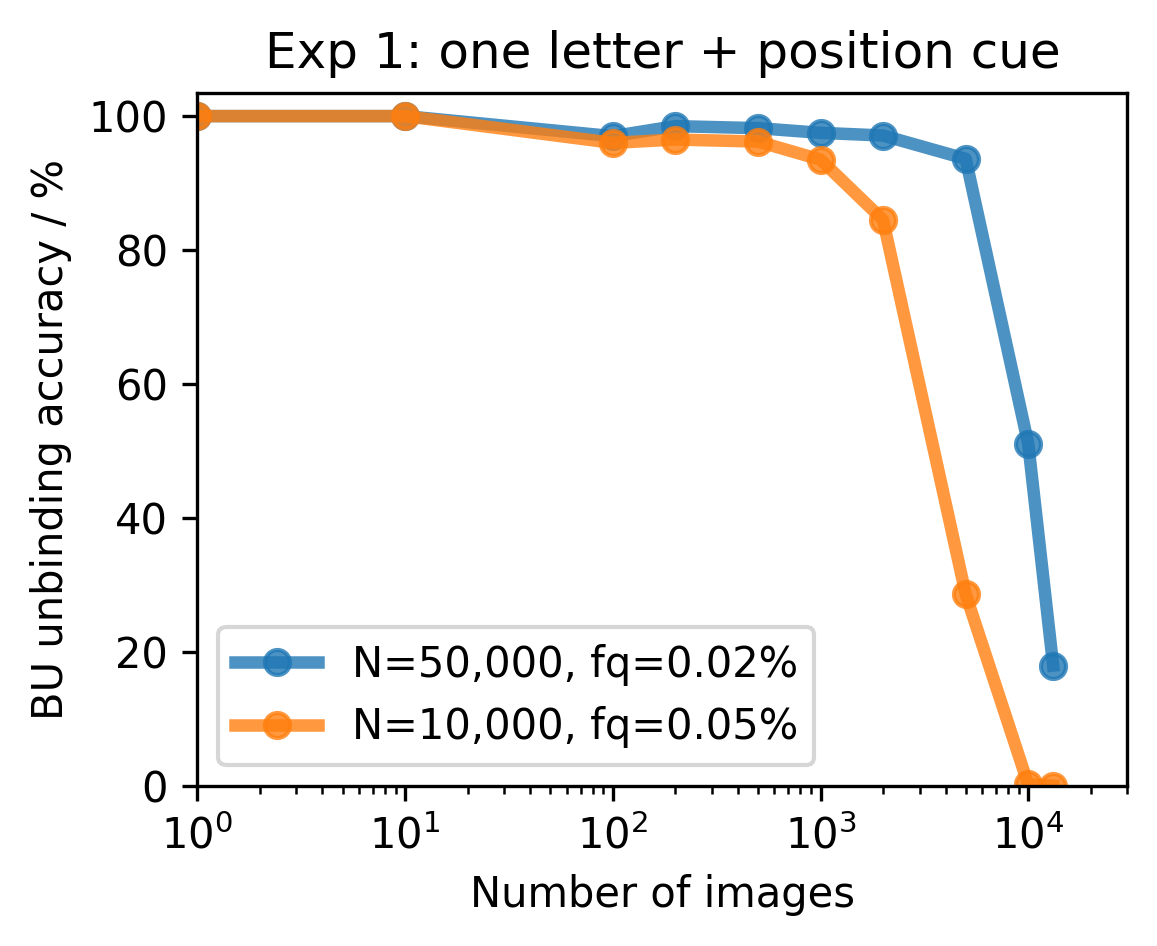

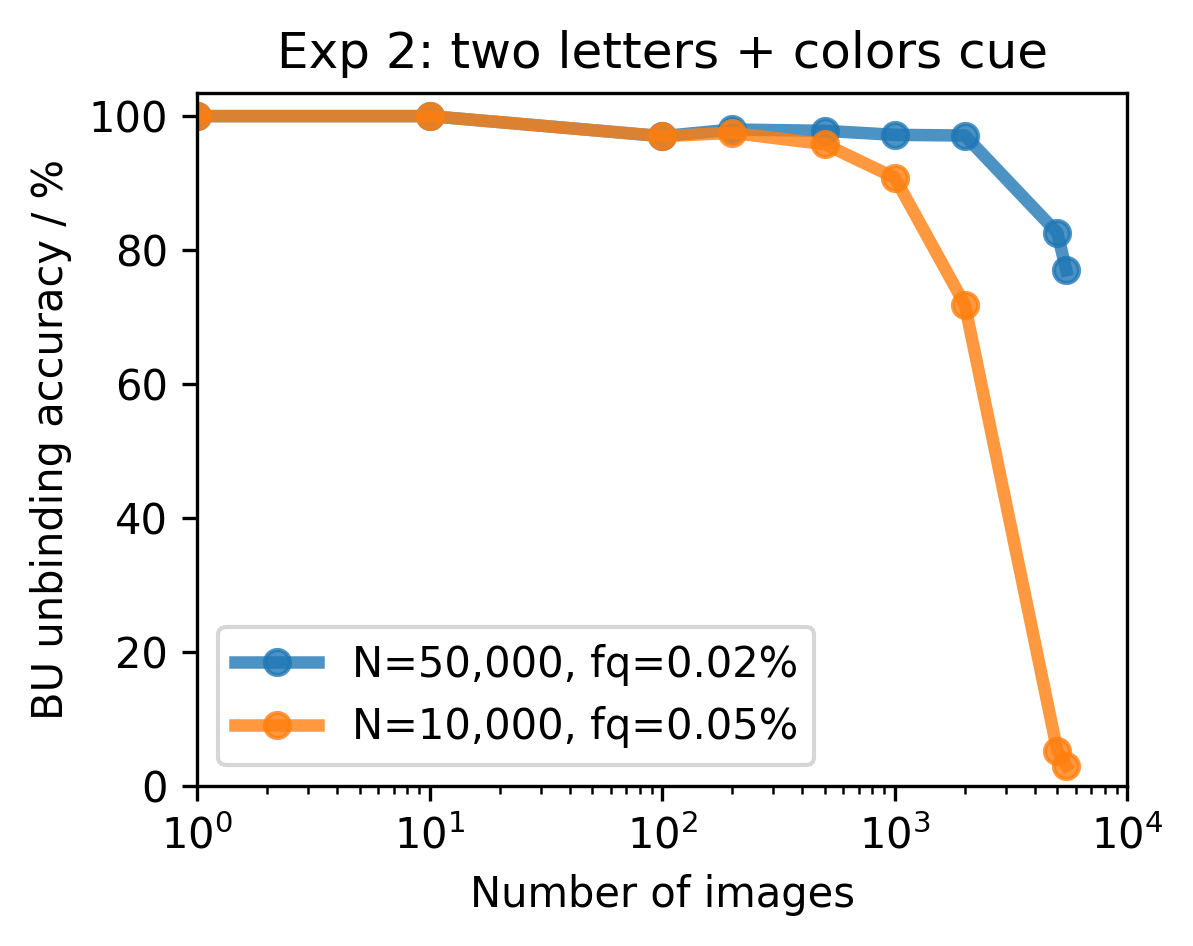

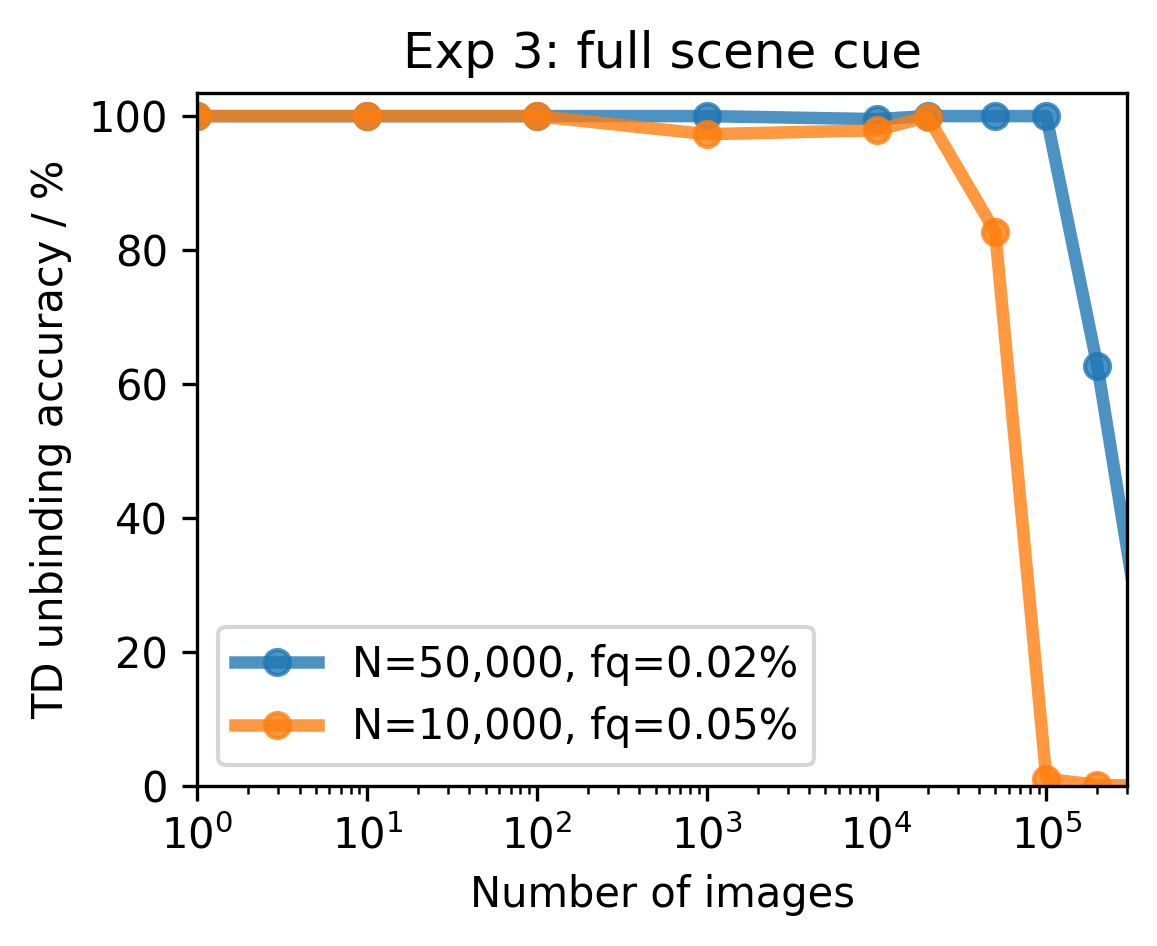


========== Summary ==========

 exp1_10000_0.0005
x_range   : [    1    10   100   200   500  1000  2000  5000 10000 13182]
exact_acc : [1.     1.     0.96   0.965  0.962  0.935  0.845  0.286  0.0019 0.    ]
bit_acc   : [1.     1.     0.9994 0.9992 0.9991 0.9987 0.9975 0.9884 0.972  0.9685]
n_eval    : [    1    10   100   200   500  1000  2000  5000 10000 13182]

 exp1_50000_0.0002
x_range   : [    1    10   100   200   500  1000  2000  5000 10000 13182]
exact_acc : [1.     1.     0.97   0.985  0.982  0.975  0.971  0.9362 0.5107 0.1794]
bit_acc   : [1.     1.     0.9999 0.9999 0.9998 0.9997 0.9997 0.9994 0.995  0.9883]
n_eval    : [    1    10   100   200   500  1000  2000  5000 10000 13182]

 exp2_10000_0.0005
x_range   : [   1   10  100  200  500 1000 2000 5000 5460]
exact_acc : [1.     1.     0.97   0.975  0.958  0.908  0.7185 0.052  0.03  ]
bit_acc   : [1.     1.     0.9999 0.9997 0.9993 0.9982 0.9952 0.9781 0.9762]
n_eval    : [   1   10  100  200  500 1000 2000 5000 5460]

 exp

In [3]:
# ============================================================
# Cached BU / TD unbinding experiments
#
# This code assumes your detector code above is already defined, including:
# - render_one_colored_letter(...)
# - detect_scene(...)
# - TOP_K
# - IMG_SIZE
# - SHIFT_MIN, SHIFT_MAX
# - LETTERS, COLOR_NAMES
# - IDX_TO_COLOR
# ============================================================

import os
import json
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


# ============================================================
# Basic config
# ============================================================

N_LETTERS = len(LETTERS)
N_COLORS = len(COLOR_NAMES)
N_LC = N_LETTERS * N_COLORS

INPUT_SIZE = N_LETTERS + N_COLORS + IMG_SIZE + IMG_SIZE
FULL_SIZE = INPUT_SIZE * 3

BU_CACHE_DIR = "./bu_td_cached_results_detector_randomslots"
os.makedirs(BU_CACHE_DIR, exist_ok=True)

CENTER_VALUES = np.arange(IMG_SIZE // 2 + SHIFT_MIN, IMG_SIZE // 2 + SHIFT_MAX + 1)
assert len(CENTER_VALUES) == 39

EXP1_MAX_SCENES = (N_LETTERS * len(CENTER_VALUES) * len(CENTER_VALUES)) // 3

# Exp 2 maximum edge-disjoint triangle packing on 182 nodes:
# build STS(183), remove one node -> 5460 triples.
EXP2_MAX_SCENES = 5460

X_RANGE_EXP1 = [1, 10, 100, 200, 500, 1000, 2000, 5000, 10000, EXP1_MAX_SCENES]
X_RANGE_EXP2 = [1, 10, 100, 200, 500, 1000, 2000, 5000, EXP2_MAX_SCENES]
X_RANGE_EXP3 = [1, 10, 100, 1000, 10000, 20000, 50000, 100000, 200000, 500000]

HP_SETS = [
    {"n_post": 10000, "p": 0.0005, "label": "N=10,000, fq=0.05%"},
    {"n_post": 50000, "p": 0.0002, "label": "N=50,000, fq=0.02%"},
]

EXP1_USE_DETECTOR_FRONTEND = True
EXP2_USE_DETECTOR_FRONTEND = True

# For Exp 3, detector on 500k images is very slow.
# Keep False unless you really want to include the visual detector frontend.
EXP3_USE_DETECTOR_FRONTEND = False

EVAL_MAX_ITEMS_EXP1 = None
EVAL_MAX_ITEMS_EXP2 = None
EVAL_MAX_ITEMS_EXP3 = 10000


# ============================================================
# Safe cache helpers
# ============================================================

def save_npz_safe(path, **kwargs):
    tmp_path = path + ".tmp.npz"
    np.savez_compressed(tmp_path, **kwargs)

    if os.path.exists(path):
        os.remove(path)

    os.rename(tmp_path, path)


def load_npz_dict(path):
    data = np.load(path, allow_pickle=True)
    return {k: data[k] for k in data.files}


def save_json(path, obj):
    tmp_path = path + ".tmp"
    with open(tmp_path, "w") as f:
        json.dump(obj, f, indent=2)
    if os.path.exists(path):
        os.remove(path)
    os.rename(tmp_path, path)


# ============================================================
# Encoding and decoding
# ============================================================

def encode_letter(letter_idx, color_idx, x, y):
    # One can pad many zeros to make this vec a 10,000 dimensional long sparse vector
    vec = np.zeros(INPUT_SIZE, dtype=np.uint8)

    if letter_idx is not None:
        vec[int(letter_idx)] = 1

    if color_idx is not None:
        vec[N_LETTERS + int(color_idx)] = 1

    if x is not None:
        vec[N_LETTERS + N_COLORS + int(x)] = 1

    if y is not None:
        vec[N_LETTERS + N_COLORS + IMG_SIZE + int(y)] = 1

    return vec


def canonicalize_scene(scene):
    scene = [tuple(map(int, row)) for row in scene]
    return sorted(scene, key=lambda z: (z[2], z[3], z[0], z[1]))

def keep_scene_order(scene):
    return [tuple(map(int, row)) for row in scene]

def randomize_slot_order_pair(gt_scene, det_scene, rng):
    """
    Detector output has no natural order.
    To avoid canonical slot bias, we first align GT and detector by canonical order,
    then apply the same random permutation to both.

    This keeps slot correspondence:
        gt_randomized[k] and det_randomized[k] refer to the same slot.
    """
    gt_aligned = np.asarray(canonicalize_scene(gt_scene), dtype=np.int16)
    det_aligned = np.asarray(canonicalize_scene(det_scene), dtype=np.int16)

    perm = rng.permutation(3)

    return gt_aligned[perm], det_aligned[perm]


def randomize_slot_order_pool(gt_scenes, det_scenes, seed=0):
    rng = np.random.default_rng(seed)

    gt_out = np.zeros_like(gt_scenes, dtype=np.int16)
    det_out = np.zeros_like(det_scenes, dtype=np.int16)

    for i in range(len(gt_scenes)):
        gt_out[i], det_out[i] = randomize_slot_order_pair(
            gt_scenes[i],
            det_scenes[i],
            rng,
        )

    return gt_out, det_out


def encode_full_scene(scene):
#     scene = canonicalize_scene(scene)
    scene = keep_scene_order(scene)

    return np.concatenate([
        encode_letter(letter_idx, color_idx, x, y)
        for letter_idx, color_idx, x, y in scene
    ]).astype(np.uint8)



def scenes_to_full_vectors_cached(scenes, cache_path, desc="encoding scenes"):
    if os.path.exists(cache_path):
        print("Loading encoded vectors:", cache_path)
        return np.load(cache_path)

    arr = np.zeros((len(scenes), FULL_SIZE), dtype=np.uint8)

    for i in tqdm(range(len(scenes)), desc=desc):
        arr[i] = encode_full_scene(scenes[i])

    np.save(cache_path, arr)
    print("Saved encoded vectors:", cache_path)
    return arr


def wta_decode_full(reconstruct):
    decoded = np.zeros(FULL_SIZE, dtype=np.uint8)

    for part in range(3):
        base = part * INPUT_SIZE

        i = np.argmax(reconstruct[base : base + N_LETTERS])
        decoded[base + i] = 1

        offset = base + N_LETTERS
        i = np.argmax(reconstruct[offset : offset + N_COLORS])
        decoded[offset + i] = 1

        offset += N_COLORS
        i = np.argmax(reconstruct[offset : offset + IMG_SIZE])
        decoded[offset + i] = 1

        offset += IMG_SIZE
        i = np.argmax(reconstruct[offset : offset + IMG_SIZE])
        decoded[offset + i] = 1

    return decoded


# ============================================================
# Canvas rendering from symbolic scene
# ============================================================

def render_canvas_from_scene(scene):
    canvas = np.zeros((3, IMG_SIZE, IMG_SIZE), dtype=np.float32)

    for letter_idx, color_idx, x, y in scene:
        dx = int(x) - IMG_SIZE // 2
        dy = int(y) - IMG_SIZE // 2

        obj = render_one_colored_letter(
            letter_idx=int(letter_idx),
            color_idx=int(color_idx),
            dx=int(dx),
            dy=int(dy),
        )

        canvas = np.maximum(canvas, obj)

    return canvas


# ============================================================
# Cue keys and validation
# ============================================================

def exp1_keys(scene):
    return [(int(row[0]), int(row[2]), int(row[3])) for row in scene]


def exp2_pair_keys(scene):
    objs = [(int(row[0]), int(row[1])) for row in scene]
    keys = []

    for a, b in itertools.combinations(objs, 2):
        key = tuple(sorted([a, b]))
        keys.append(key)

    return keys


def validate_exp1_pool(scenes):
    used = set()

    for scene in scenes:
        keys = exp1_keys(scene)

        if len(set(keys)) != 3:
            return False, "duplicate Exp1 cue inside one scene"

        for k in keys:
            if k in used:
                return False, f"repeated Exp1 cue across dataset: {k}"
            used.add(k)

    return True, f"ok, used {len(used)} Exp1 cue keys"


def validate_exp2_pool(scenes):
    used = set()

    for scene in scenes:
        keys = exp2_pair_keys(scene)

        if len(set(keys)) != 3:
            return False, "duplicate Exp2 cue pair inside one scene"

        for k in keys:
            if k in used:
                return False, f"repeated Exp2 cue pair across dataset: {k}"
            used.add(k)

    return True, f"ok, used {len(used)} Exp2 pair keys"


# ============================================================
# Letter-color identity helpers
# ============================================================

def lc_to_letter_color(lc_idx):
    letter_idx = int(lc_idx) // N_COLORS
    color_idx = int(lc_idx) % N_COLORS
    return letter_idx, color_idx


def letter_color_to_lc(letter_idx, color_idx):
    return int(letter_idx) * N_COLORS + int(color_idx)


# ============================================================
# Exp 1 GT pool
# ============================================================

def build_exp1_gt_pool(max_images, seed=111):
    """
    Exp 1 cue uniqueness:
        every (letter, x, y) appears at most once across the dataset.

    Construction:
        enumerate all (letter, x, y) slots, shuffle, group every 3 slots.
    """
    cache_path = os.path.join(
        BU_CACHE_DIR,
        f"exp1_gt_pool_n{max_images}_seed{seed}.npy"
    )

    if os.path.exists(cache_path):
        print("Loading Exp 1 GT pool:", cache_path)
        return np.load(cache_path)

    if max_images > EXP1_MAX_SCENES:
        raise ValueError(f"Exp 1 requested {max_images}, but max is {EXP1_MAX_SCENES}.")

    rng = np.random.default_rng(seed)

    slots = []
    for letter_idx in range(N_LETTERS):
        for x in CENTER_VALUES:
            for y in CENTER_VALUES:
                slots.append((letter_idx, int(x), int(y)))

    slots = np.asarray(slots, dtype=np.int16)
    rng.shuffle(slots)

    needed = max_images * 3
    slots = slots[:needed].copy()

    # Fix rare within-scene same-center collisions by swapping with later slots.
    for i in tqdm(range(max_images), desc="fixing Exp1 same-center cases"):
        start = i * 3
        end = start + 3

        group = slots[start:end]
        centers = [(int(row[1]), int(row[2])) for row in group]

        if len(set(centers)) == 3:
            continue

        fixed = False

        for j in range(end, needed):
            for k in range(3):
                trial = slots[start:end].copy()
                trial[k] = slots[j]
                trial_centers = [(int(row[1]), int(row[2])) for row in trial]

                if len(set(trial_centers)) == 3:
                    tmp = slots[start + k].copy()
                    slots[start + k] = slots[j]
                    slots[j] = tmp
                    fixed = True
                    break

            if fixed:
                break

        if not fixed:
            raise RuntimeError(f"Could not fix same-center case at scene {i}")

    scenes = np.zeros((max_images, 3, 4), dtype=np.int16)

    for i in tqdm(range(max_images), desc="building Exp 1 GT scenes"):
        slot_scene = slots[i * 3 : i * 3 + 3]

        objs = []
        for letter_idx, x, y in slot_scene:
            color_idx = int(rng.integers(0, N_COLORS))
            objs.append((int(letter_idx), color_idx, int(x), int(y)))

#         scenes[i] = np.asarray(canonicalize_scene(objs), dtype=np.int16)
        scenes[i] = np.asarray(objs, dtype=np.int16)

    ok, msg = validate_exp1_pool(scenes)
    print("Exp 1 validation:", ok, msg)
    if not ok:
        raise RuntimeError(msg)

    np.save(cache_path, scenes)
    print("Saved Exp 1 GT pool:", cache_path)
    return scenes


# ============================================================
# Exp 2 exact maximum edge-disjoint triangle pool
# ============================================================

def build_edge_disjoint_lc_triples_exact(n_images, seed=222):
    """
    Deterministically construct edge-disjoint triples over N_LC=182 nodes.

    Construction:
        Build Steiner triple system STS(183) using Bose construction.
        Remove one point.
        Remaining triples give exactly 5460 edge-disjoint triples on 182 nodes.

    Each triple corresponds to 3 (letter,color) objects.
    Every unordered pair of (letter,color) identities appears at most once.
    """
    max_images = EXP2_MAX_SCENES

    if n_images > max_images:
        raise ValueError(f"Exp 2 requested {n_images}, but max is {max_images}.")

    cache_path = os.path.join(
        BU_CACHE_DIR,
        f"exp2_lc_triples_exact_n{n_images}_seed{seed}.npy"
    )

    if os.path.exists(cache_path):
        print("Loading exact Exp 2 LC triples:", cache_path)
        return np.load(cache_path)

    # Bose construction for STS(6t+3).
    # 183 = 6*30 + 3.
    # Let m = 2t + 1 = 61.
    m = 61
    inv2 = pow(2, -1, m)

    def point_id(x, r):
        return x * 3 + r

    removed_point = point_id(0, 0)

    blocks = []

    # Type 1 blocks
    for x in range(m):
        block = [point_id(x, 0), point_id(x, 1), point_id(x, 2)]
        if removed_point not in block:
            blocks.append(tuple(block))

    # Type 2 blocks
    for x in range(m):
        for y in range(x + 1, m):
            mid = ((x + y) * inv2) % m

            for r in range(3):
                block = [
                    point_id(x, r),
                    point_id(y, r),
                    point_id(mid, (r + 1) % 3),
                ]

                if removed_point not in block:
                    blocks.append(tuple(block))

    remaining_points = [p for p in range(183) if p != removed_point]
    point_to_lc = {p: i for i, p in enumerate(remaining_points)}

    triples = []
    for block in blocks:
        triples.append(tuple(sorted(point_to_lc[p] for p in block)))

    triples = np.asarray(triples, dtype=np.uint16)

    assert triples.shape[0] == EXP2_MAX_SCENES, triples.shape

    used_edges = set()

    for a, b, c in triples:
        a, b, c = int(a), int(b), int(c)

        for u, v in [(a, b), (a, c), (b, c)]:
            if u > v:
                u, v = v, u

            if (u, v) in used_edges:
                raise RuntimeError(f"Repeated Exp2 pair edge: {(u, v)}")

            used_edges.add((u, v))

    assert len(used_edges) == EXP2_MAX_SCENES * 3

    rng = np.random.default_rng(seed)
    rng.shuffle(triples)

    triples = triples[:n_images].copy()

    np.save(cache_path, triples)
    print("Saved exact Exp 2 LC triples:", cache_path)
    print("Number of triples:", len(triples))
    print("Number of used pair cues:", len(triples) * 3)

    return triples


def build_exp2_gt_pool(max_images, seed=222):
    """
    Exp 2 cue uniqueness:
        every unordered pair of (letter,color) identities appears at most once.

    Construction:
        exact edge-disjoint triangle packing on 182 LC identities.
        Then assign distinct random centers to the 3 objects.
    """
    cache_path = os.path.join(
        BU_CACHE_DIR,
        f"exp2_gt_pool_n{max_images}_seed{seed}.npy"
    )

    if os.path.exists(cache_path):
        print("Loading Exp 2 GT pool:", cache_path)
        return np.load(cache_path)

    rng = np.random.default_rng(seed)
    lc_triples = build_edge_disjoint_lc_triples_exact(max_images, seed=seed)

    center_list = [(int(x), int(y)) for x in CENTER_VALUES for y in CENTER_VALUES]
    scenes = np.zeros((max_images, 3, 4), dtype=np.int16)

    for i in tqdm(range(max_images), desc="building Exp 2 GT scenes"):
        center_idx = rng.choice(len(center_list), size=3, replace=False)
        centers = [center_list[int(j)] for j in center_idx]

        objs = []
        for lc_idx, (x, y) in zip(lc_triples[i], centers):
            letter_idx, color_idx = lc_to_letter_color(int(lc_idx))
            objs.append((letter_idx, color_idx, int(x), int(y)))

#         scenes[i] = np.asarray(canonicalize_scene(objs), dtype=np.int16)
        scenes[i] = np.asarray(objs, dtype=np.int16)

    ok, msg = validate_exp2_pool(scenes)
    print("Exp 2 validation:", ok, msg)
    if not ok:
        raise RuntimeError(msg)

    np.save(cache_path, scenes)
    print("Saved Exp 2 GT pool:", cache_path)
    return scenes


# ============================================================
# Exp 3 free GT pool
# ============================================================

def build_exp3_gt_pool(max_images, seed=333):
    """
    Exp 3 cue is full scene, so no dataset-wide cue uniqueness is needed.
    Within each scene, same center is disallowed.
    """
    cache_path = os.path.join(
        BU_CACHE_DIR,
        f"exp3_gt_pool_n{max_images}_seed{seed}.npy"
    )

    if os.path.exists(cache_path):
        print("Loading Exp 3 GT pool:", cache_path)
        return np.load(cache_path)

    rng = np.random.default_rng(seed)
    center_list = [(int(x), int(y)) for x in CENTER_VALUES for y in CENTER_VALUES]

    scenes = np.zeros((max_images, 3, 4), dtype=np.int16)

    for i in tqdm(range(max_images), desc="building Exp 3 GT scenes"):
        center_idx = rng.choice(len(center_list), size=3, replace=False)

        objs = []
        for j in range(3):
            letter_idx = int(rng.integers(0, N_LETTERS))
            color_idx = int(rng.integers(0, N_COLORS))
            x, y = center_list[int(center_idx[j])]
            objs.append((letter_idx, color_idx, int(x), int(y)))

#         scenes[i] = np.asarray(canonicalize_scene(objs), dtype=np.int16)
        scenes[i] = np.asarray(objs, dtype=np.int16)

    np.save(cache_path, scenes)
    print("Saved Exp 3 GT pool:", cache_path)
    return scenes


# ============================================================
# Detector frontend caching
# ============================================================

def apply_detector_to_pool_cached(gt_scenes, exp_name, seed, use_detector_frontend=True, save_every=100):
    """
    Returns det_scenes.
    If use_detector_frontend=False, det_scenes = gt_scenes.
    If True, runs detect_scene on rendered canvases and saves progress.
    """
    n_images = len(gt_scenes)

    cache_path = os.path.join(
        BU_CACHE_DIR,
        f"{exp_name}_det_pool_n{n_images}_seed{seed}_det{int(use_detector_frontend)}.npz"
    )

    if os.path.exists(cache_path):
        obj = load_npz_dict(cache_path)
        det_scenes = obj["det_scenes"]
        done = int(obj["done"])

        print(f"Loading detector cache: {cache_path}")
        print(f"done={done}/{n_images}")

        if done >= n_images:
            return det_scenes

    else:
        if not use_detector_frontend:
            det_scenes = gt_scenes.copy()
            save_npz_safe(
                cache_path,
                det_scenes=det_scenes,
                done=np.array(n_images, dtype=np.int32),
            )
            print("Saved no-detector detected pool:", cache_path)
            return det_scenes

        det_scenes = np.zeros_like(gt_scenes, dtype=np.int16)
        done = 0

    exact = 0

    if done > 0:
        exact = int(np.sum(np.all(det_scenes[:done] == gt_scenes[:done], axis=(1, 2))))

    for i in tqdm(range(done, n_images), desc=f"detecting {exp_name}"):
        canvas = render_canvas_from_scene(gt_scenes[i])
        det = detect_scene(canvas, top_k=TOP_K)
        det_scenes[i] = det

        if np.array_equal(det, gt_scenes[i]):
            exact += 1

        if ((i + 1) % save_every == 0) or ((i + 1) == n_images):
            save_npz_safe(
                cache_path,
                det_scenes=det_scenes,
                done=np.array(i + 1, dtype=np.int32),
            )

    acc = float(np.mean(np.all(det_scenes == gt_scenes, axis=(1, 2))))
    print(f"{exp_name} detector exact scene acc: {acc:.4f}")
    print("Saved detector cache:", cache_path)

    meta_path = cache_path.replace(".npz", "_meta.json")
    save_json(
        meta_path,
        {
            "exp_name": exp_name,
            "n_images": int(n_images),
            "use_detector_frontend": bool(use_detector_frontend),
            "detector_exact_scene_acc": acc,
        }
    )

    return det_scenes


# ============================================================
# Cue construction with caching
# ============================================================

def build_cues_exp1_cached(det_scenes, cache_path):
    if os.path.exists(cache_path):
        print("Loading Exp 1 cue vectors:", cache_path)
        return np.load(cache_path)

    cues = np.zeros((len(det_scenes), FULL_SIZE), dtype=np.uint8)

    for i in tqdm(range(len(det_scenes)), desc="building Exp 1 cues"):
#         scene = canonicalize_scene(det_scenes[i])
        scene = keep_scene_order(det_scenes[i])
        l0, c0, x0, y0 = scene[0]

        cues[i] = np.concatenate([
            encode_letter(l0, None, x0, y0),
            np.zeros(INPUT_SIZE, dtype=np.uint8),
            np.zeros(INPUT_SIZE, dtype=np.uint8),
        ])

    np.save(cache_path, cues)
    print("Saved Exp 1 cue vectors:", cache_path)
    return cues



def build_cues_exp2_cached(det_scenes, cache_path):
    if os.path.exists(cache_path):
        print("Loading Exp 2 cue vectors:", cache_path)
        return np.load(cache_path)

    cues = np.zeros((len(det_scenes), FULL_SIZE), dtype=np.uint8)

    for i in tqdm(range(len(det_scenes)), desc="building Exp 2 cues"):
#         scene = canonicalize_scene(det_scenes[i])
        scene = keep_scene_order(det_scenes[i])
        l0, c0, x0, y0 = scene[0]
        l1, c1, x1, y1 = scene[1]

        cues[i] = np.concatenate([
            encode_letter(l0, c0, None, None),
            encode_letter(l1, c1, None, None),
            np.zeros(INPUT_SIZE, dtype=np.uint8),
        ])

    np.save(cache_path, cues)
    print("Saved Exp 2 cue vectors:", cache_path)
    return cues



def prepare_experiment_data_cached(exp_name, max_images, seed, use_detector_frontend, randomize_slots=False):
    """
    Returns:
        gt_scenes, det_scenes, det_full, cue, gt_full
    """
    if exp_name == "exp1":
        gt_scenes = build_exp1_gt_pool(max_images=max_images, seed=seed)
    elif exp_name == "exp2":
        gt_scenes = build_exp2_gt_pool(max_images=max_images, seed=seed)
    elif exp_name == "exp3":
        gt_scenes = build_exp3_gt_pool(max_images=max_images, seed=seed)
    else:
        raise ValueError(exp_name)

    det_scenes = apply_detector_to_pool_cached(
        gt_scenes=gt_scenes,
        exp_name=exp_name,
        seed=seed,
        use_detector_frontend=use_detector_frontend,
        save_every=100,
    )

    if randomize_slots:
        rand_path = os.path.join(
            BU_CACHE_DIR,
            f"{exp_name}_slot_randomized_n{max_images}_seed{seed}_det{int(use_detector_frontend)}.npz"
        )

        if os.path.exists(rand_path):
            print("Loading slot-randomized scenes:", rand_path)
            obj = load_npz_dict(rand_path)
            gt_scenes = obj["gt_scenes"]
            det_scenes = obj["det_scenes"]
        else:
            print(f"Randomizing slot order for {exp_name} ...")
            gt_scenes, det_scenes = randomize_slot_order_pool(
                gt_scenes=gt_scenes,
                det_scenes=det_scenes,
                seed=seed + 999,
            )

            save_npz_safe(
                rand_path,
                gt_scenes=gt_scenes,
                det_scenes=det_scenes,
            )
            print("Saved slot-randomized scenes:", rand_path)

    gt_full_path = os.path.join(
        BU_CACHE_DIR,
        f"{exp_name}_gt_full_n{max_images}_seed{seed}_det{int(use_detector_frontend)}_rand{int(randomize_slots)}.npy"
    )
    det_full_path = os.path.join(
        BU_CACHE_DIR,
        f"{exp_name}_det_full_n{max_images}_seed{seed}_det{int(use_detector_frontend)}_rand{int(randomize_slots)}.npy"
    )
    cue_path = os.path.join(
        BU_CACHE_DIR,
        f"{exp_name}_cue_n{max_images}_seed{seed}_det{int(use_detector_frontend)}_rand{int(randomize_slots)}.npy"
    )

    gt_full = scenes_to_full_vectors_cached(
        gt_scenes,
        cache_path=gt_full_path,
        desc=f"encoding {exp_name} GT full vectors",
    )

    det_full = scenes_to_full_vectors_cached(
        det_scenes,
        cache_path=det_full_path,
        desc=f"encoding {exp_name} detected full vectors",
    )

    if exp_name == "exp1":
        cue = build_cues_exp1_cached(det_scenes, cache_path=cue_path)
    elif exp_name == "exp2":
        cue = build_cues_exp2_cached(det_scenes, cache_path=cue_path)
    elif exp_name == "exp3":
        if os.path.exists(cue_path):
            print("Loading Exp 3 cue vectors:", cue_path)
            cue = np.load(cue_path)
        else:
            cue = det_full.copy()
            np.save(cue_path, cue)
            print("Saved Exp 3 cue vectors:", cue_path)

    return gt_scenes, det_scenes, det_full, cue, gt_full


# ============================================================
# Memory model
# ============================================================

def memory_update(W_ff, W_fb, full_input, rng, p):
    selected = rng.random(W_ff.shape[0]) <= p

    if not np.any(selected):
        return

    sel_idx = np.flatnonzero(selected)
    active_idx = np.flatnonzero(full_input)

    if len(active_idx) == 0:
        return

    sub = W_ff[np.ix_(sel_idx, active_idx)]
    set_to_1 = sub == 0

    # Same toggling rule as your original code.
    W_ff[np.ix_(sel_idx, active_idx)] = 1 - sub

    # Feedback weights are set to 1 only for newly set FF weights.
    rows, cols = np.where(set_to_1.T)

    if len(rows) > 0:
        W_fb[active_idx[rows], sel_idx[cols]] = 1


def evaluate_memory(W_ff, W_fb, cues, targets, threshold, max_items=None):
    n_total = len(cues)

    if max_items is None or max_items >= n_total:
        eval_idx = np.arange(n_total)
    else:
        eval_idx = np.linspace(0, n_total - 1, max_items).astype(int)

    W_ff_i = W_ff.astype(np.int16, copy=False)
    W_fb_i = W_fb.astype(np.int16, copy=False)

    bit_accs = []
    exacts = []

    for idx in eval_idx:
        cue = cues[idx].astype(np.int16, copy=False)
        target = targets[idx].astype(np.uint8, copy=False)

        hidden = (W_ff_i @ cue) > threshold
        reconstruct = W_fb_i @ hidden.astype(np.int16)

        decoded = wta_decode_full(reconstruct)

        bit_accs.append(np.mean(decoded == target))
        exacts.append(float(np.array_equal(decoded, target)))

    return {
        "bit_acc": float(np.mean(bit_accs)),
        "exact_acc": float(np.mean(exacts)),
        "n_eval": int(len(eval_idx)),
    }



def run_curve_incremental_checkpointed(
    train_vectors,
    cue_vectors,
    target_vectors,
    x_range,
    n_post,
    p,
    threshold,
    seed=0,
    max_eval_items=None,
    cache_name="experiment",
    cache_dir=BU_CACHE_DIR,
    force_restart=False,
):
    os.makedirs(cache_dir, exist_ok=True)

    ckpt_path = os.path.join(
        cache_dir,
        f"{cache_name}_npost{n_post}_p{p}_thr{threshold}_seed{seed}.npz"
    )

    x_range = list(x_range)
    max_n = max(x_range)
    x_set = set(x_range)

    rng = np.random.default_rng(seed)

    if os.path.exists(ckpt_path) and not force_restart:
        print("Loading memory checkpoint:", ckpt_path)
        ckpt = np.load(ckpt_path, allow_pickle=True)

        W_ff = ckpt["W_ff"]
        W_fb = ckpt["W_fb"]
        start_i = int(ckpt["current_i"])

        results = {
            "x_range": ckpt["x_range"].tolist(),
            "bit_acc": ckpt["bit_acc"].tolist(),
            "exact_acc": ckpt["exact_acc"].tolist(),
            "n_eval": ckpt["n_eval"].tolist(),
        }

        rng_state = ckpt["rng_state"].item()
        rng.bit_generator.state = rng_state

        print(f"Resuming from sample {start_i}")
        print("Finished datapoints:", results["x_range"])

    else:
        print("Starting new memory run:", ckpt_path)

        W_ff = np.zeros((n_post, FULL_SIZE), dtype=np.uint8)
        W_fb = np.zeros((FULL_SIZE, n_post), dtype=np.uint8)
        start_i = 0

        results = {
            "x_range": [],
            "bit_acc": [],
            "exact_acc": [],
            "n_eval": [],
        }

    for i in tqdm(range(start_i, max_n), desc=f"training {cache_name}, N={n_post}, p={p}"):
        memory_update(W_ff, W_fb, train_vectors[i], rng, p)

        current_n = i + 1

        if current_n in x_set:
            stats = evaluate_memory(
                W_ff=W_ff,
                W_fb=W_fb,
                cues=cue_vectors[:current_n],
                targets=target_vectors[:current_n],
                threshold=threshold,
                max_items=max_eval_items,
            )

            print(
                f"{cache_name}, N={n_post}, p={p}, samples={current_n}, "
                f"bit_acc={stats['bit_acc']:.4f}, "
                f"exact_acc={stats['exact_acc']:.4f}, "
                f"n_eval={stats['n_eval']}"
            )

            if current_n not in results["x_range"]:
                results["x_range"].append(current_n)
                results["bit_acc"].append(stats["bit_acc"])
                results["exact_acc"].append(stats["exact_acc"])
                results["n_eval"].append(stats["n_eval"])

            save_npz_safe(
                ckpt_path,
                W_ff=W_ff,
                W_fb=W_fb,
                current_i=np.array(current_n, dtype=np.int64),
                x_range=np.asarray(results["x_range"]),
                bit_acc=np.asarray(results["bit_acc"]),
                exact_acc=np.asarray(results["exact_acc"]),
                n_eval=np.asarray(results["n_eval"]),
                rng_state=np.array(rng.bit_generator.state, dtype=object),
            )

            print("Saved memory checkpoint:", ckpt_path)

    final_results = {
        "x_range": np.asarray(results["x_range"]),
        "bit_acc": np.asarray(results["bit_acc"]),
        "exact_acc": np.asarray(results["exact_acc"]),
        "n_eval": np.asarray(results["n_eval"]),
    }

    final_path = os.path.join(
        cache_dir,
        f"{cache_name}_npost{n_post}_p{p}_thr{threshold}_seed{seed}_final.npy"
    )
    np.save(final_path, final_results, allow_pickle=True)

    print("Saved final memory results:", final_path)
    return final_results


# ============================================================
# Plotting
# ============================================================

def plot_curve_pair(res_10000, res_50000, ylabel, title, xlim, ylim):
    plt.figure(figsize=(4, 3), dpi=300)

    plt.plot(
        res_50000["x_range"],
        res_50000["exact_acc"] * 100,
        marker="o",
        lw=3,
        label="N=50,000, fq=0.02%",
        alpha=.8,
    )

    plt.plot(
        res_10000["x_range"],
        res_10000["exact_acc"] * 100,
        marker="o",
        lw=3,
        label="N=10,000, fq=0.05%",
        alpha=.8,
    )

    plt.xscale("log")
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.xlabel("Number of images")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


# ============================================================
# Prepare cached datasets
# ============================================================

max_exp1 = max(X_RANGE_EXP1)
max_exp2 = max(X_RANGE_EXP2)
max_exp3 = max(X_RANGE_EXP3)

print("\n========== Prepare Exp 1 data ==========")
gt_scenes_exp1, det_scenes_exp1, det_full_exp1, cue_exp1, gt_full_exp1 = prepare_experiment_data_cached(
    exp_name="exp1",
    max_images=max_exp1,
    seed=111,
    use_detector_frontend=EXP1_USE_DETECTOR_FRONTEND,
)
gt_scenes_exp1, det_scenes_exp1, det_full_exp1, cue_exp1, gt_full_exp1 = prepare_experiment_data_cached(
    exp_name="exp1",
    max_images=max_exp1,
    seed=111,
    use_detector_frontend=True,
    randomize_slots=True,
)

print("\n========== Prepare Exp 2 data ==========")
gt_scenes_exp2, det_scenes_exp2, det_full_exp2, cue_exp2, gt_full_exp2 = prepare_experiment_data_cached(
    exp_name="exp2",
    max_images=max_exp2,
    seed=222,
    use_detector_frontend=EXP2_USE_DETECTOR_FRONTEND,
)


gt_scenes_exp2, det_scenes_exp2, det_full_exp2, cue_exp2, gt_full_exp2 = prepare_experiment_data_cached(
    exp_name="exp2",
    max_images=max_exp2,
    seed=222,
    use_detector_frontend=True,
    randomize_slots=True,
)

print("\n========== Prepare Exp 3 data ==========")
gt_scenes_exp3, det_scenes_exp3, det_full_exp3, cue_exp3, gt_full_exp3 = prepare_experiment_data_cached(
    exp_name="exp3",
    max_images=max_exp3,
    seed=333,
    use_detector_frontend=EXP3_USE_DETECTOR_FRONTEND,
)


# ============================================================
# Run experiments with memory checkpoints
# ============================================================

all_results = {}

print("\n========== Exp 1: BU cue = one letter + position ==========")
for hp in HP_SETS:
    res = run_curve_incremental_checkpointed(
        train_vectors=det_full_exp1,
        cue_vectors=cue_exp1,
        target_vectors=gt_full_exp1,
        x_range=X_RANGE_EXP1,
        n_post=hp["n_post"],
        p=hp["p"],
        threshold=2,
        seed=1000 + hp["n_post"],
        max_eval_items=EVAL_MAX_ITEMS_EXP1,
        cache_name="exp1_BU_one_letter_position",
        force_restart=False,
    )
    all_results[f"exp1_{hp['n_post']}_{hp['p']}"] = res


print("\n========== Exp 2: BU cue = two letters + colors ==========")
for hp in HP_SETS:
    res = run_curve_incremental_checkpointed(
        train_vectors=det_full_exp2,
        cue_vectors=cue_exp2,
        target_vectors=gt_full_exp2,
        x_range=X_RANGE_EXP2,
        n_post=hp["n_post"],
        p=hp["p"],
        threshold=3,
        seed=2000 + hp["n_post"],
        max_eval_items=EVAL_MAX_ITEMS_EXP2,
        cache_name="exp2_BU_two_letters_colors",
        force_restart=False,
    )
    all_results[f"exp2_{hp['n_post']}_{hp['p']}"] = res


print("\n========== Exp 3: TD cue = full scene ==========")
for hp in HP_SETS:
    res = run_curve_incremental_checkpointed(
        train_vectors=det_full_exp3,
        cue_vectors=cue_exp3,
        target_vectors=gt_full_exp3,
        x_range=X_RANGE_EXP3,
        n_post=hp["n_post"],
        p=hp["p"],
        threshold=6,
        seed=3000 + hp["n_post"],
        max_eval_items=EVAL_MAX_ITEMS_EXP3,
        cache_name="exp3_TD_full_scene",
        force_restart=False,
    )
    all_results[f"exp3_{hp['n_post']}_{hp['p']}"] = res


# ============================================================
# Save all final results
# ============================================================

all_results_path = os.path.join(BU_CACHE_DIR, "all_bu_td_results_cached.npy")
np.save(all_results_path, all_results, allow_pickle=True)
print("Saved all results:", all_results_path)


# ============================================================
# Plots
# ============================================================

plot_curve_pair(
    res_10000=all_results["exp1_10000_0.0005"],
    res_50000=all_results["exp1_50000_0.0002"],
    ylabel="BU unbinding accuracy / %",
    title="Exp 1: one letter + position cue",
    xlim=(1, 30000),
    ylim=(0, 103.5),
)

plot_curve_pair(
    res_10000=all_results["exp2_10000_0.0005"],
    res_50000=all_results["exp2_50000_0.0002"],
    ylabel="BU unbinding accuracy / %",
    title="Exp 2: two letters + colors cue",
    xlim=(1, 10000),
    ylim=(0, 103.5),
)

plot_curve_pair(
    res_10000=all_results["exp3_10000_0.0005"],
    res_50000=all_results["exp3_50000_0.0002"],
    ylabel="TD unbinding accuracy / %",
    title="Exp 3: full scene cue",
    xlim=(1, 300000),
    ylim=(0, 103.5),
)


# ============================================================
# Summary
# ============================================================

print("\n========== Summary ==========")
for key, res in all_results.items():
    print("\n", key)
    print("x_range   :", res["x_range"])
    print("exact_acc :", np.round(res["exact_acc"], 4))
    print("bit_acc   :", np.round(res["bit_acc"], 4))
    print("n_eval    :", res["n_eval"])